## Fan data - T cells removal 
## GBM from malmberg and ding data
## Bar plot comparing GBM vs BrM_LC and BrM_BC

In [ ]:
#python version-3.9.6

# Fan data T cells removal 

In [2]:
import scanpy as sc
import anndata
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load Fan data

In [3]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Fan_brain_met/Xing_rds/batch_none/Fan_nk_eMLclassified_adata_batch_none_classification_patientID.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 10353 × 4000
    obs: 'Disease', 'Study', 'SampleID', 'CancerType', 'CancerSubtype', 'EGFRtype', 'Treatment', 'Celltype', 'Subtype', 'batch', 'celltype.l2', 'dataset_name', '_scvi_labels', '_scvi_batch', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC', 'classification', 'PatientID'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_totalvi_scarches', 'protein_expression'
    layers: 'counts'

In [5]:
adata.obs

,Disease,Study,SampleID,CancerType,CancerSubtype,EGFRtype,Treatment,Celltype,Subtype,batch,...,dataset_name,_scvi_labels,_scvi_batch,CD56brightBBCprob,CD56dimBBCprob,eML1BBCprob,eML2BBCprob,predictionsBBC,classification,PatientID
Xing_BrM02_LC_AATGGAACAACGGCCT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,...,Query,0,3,0.005730,0.565306,0.372211,0.056753,CD56dim,CD56dim,BrM02
Xing_BrM02_LC_AGTGTTGGTGAATGTA,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,...,Query,0,3,0.000500,0.963111,0.032505,0.003885,CD56dim,CD56dim,BrM02
Xing_BrM02_LC_CCACAAAAGACCGTTT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,...,Query,0,3,0.000239,0.862482,0.113108,0.024171,CD56dim,CD56dim,BrM02
Xing_BrM02_LC_CGAAGGATCACCACAA,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L22 : NK-IFN,SampleID,...,Query,0,3,0.000392,0.840216,0.052103,0.107289,CD56dim,CD56dim,BrM02
Xing_BrM02_LC_CTAGACAAGTAAGCAT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,...,Query,0,3,0.000249,0.934569,0.045763,0.019419,CD56dim,CD56dim,BrM02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Xing_BrM99_HCC_TTTAGTCGTGCCTTCT,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,...,Query,0,3,0.000207,0.969836,0.004853,0.025104,CD56dim,CD56dim,BrM99
Xing_BrM99_HCC_TTTATGCTCCACTGGG,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L19 : NK-NCAM1,SampleID,...,Query,0,3,0.070726,0.238062,0.549249,0.141963,ML1,ML1,BrM99
Xing_BrM99_HCC_TTTGATCGTGCGACAA,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L19 : NK-NCAM1,SampleID,...,Query,0,3,0.000998,0.663616,0.077892,0.257494,CD56dim,CD56dim,BrM99
Xing_BrM99_HCC_TTTGGAGTCAACCTTT,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,...,Query,0,3,0.004836,0.918610,0.024485,0.052069,CD56dim,CD56dim,BrM99


In [6]:
adata.obs.groupby("CancerSubtype")["SampleID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_30312/2382057788.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("CancerSubtype")["SampleID"].nunique()


CancerSubtype
BC-HR+HER2+     4
BC-HR+HER2-     2
BC-HR-HER2+     6
BC-TNBC         4
LC-SCLC         6
NSCLC-LCLC      3
NSCLC-LUAD     28
NSCLC-LUSC      3
Other          23
Name: SampleID, dtype: int64

In [7]:
adata.obs["CancerType"].value_counts()

CancerType
LC         5486
HCC        1301
BC         1262
CRC        1243
Other       338
ESCC        313
MEL         286
Sarcoma     124
Name: count, dtype: int64

In [8]:
adata.obs.groupby("CancerType")["PatientID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_30312/3386323913.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("CancerType")["PatientID"].nunique()


CancerType
BC         16
CRC         7
ESCC        3
HCC         3
LC         39
MEL         1
Other       4
Sarcoma     4
Name: PatientID, dtype: int64

In [9]:
adata.obs["classification"].value_counts()

classification
CD56dim          6124
ML1              1761
ML_transition     816
CD56bright        785
ML2               508
unclassified      359
Name: count, dtype: int64

Adding expression of all genes from original data to classified data

In [10]:
#prepped adata load/original ann data
prep_adata = sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Fan_brain_met/Xing_rds/batch_none/Fan_nk_prepped_batch_none.h5ad")

In [11]:
prep_adata

AnnData object with n_obs × n_vars = 10353 × 33694
    obs: 'Disease', 'Study', 'SampleID', 'CancerType', 'CancerSubtype', 'EGFRtype', 'Treatment', 'Celltype', 'Subtype', 'batch', 'celltype.l2', 'dataset_name'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [12]:
# Make sure both objects have aligned indices 
common_cells = adata.obs_names.intersection(prep_adata.obs_names)

In [13]:
# Add the classification column from adata to prep data
prep_adata.obs.loc[common_cells, 'classification'] = adata.obs.loc[common_cells, 'classification']
prep_adata.obs.loc[common_cells, 'PatientID'] = adata.obs.loc[common_cells, 'PatientID']

In [14]:
prep_adata.obs["classification"].value_counts()

classification
CD56dim          6124
ML1              1761
ML_transition     816
CD56bright        785
ML2               508
unclassified      359
Name: count, dtype: int64

In [15]:
prep_adata.obs["CancerType"].value_counts()

CancerType
LC         5486
HCC        1301
BC         1262
CRC        1243
Other       338
ESCC        313
MEL         286
Sarcoma     124
Name: count, dtype: int64

In [16]:
prep_adata.obs.groupby("CancerSubtype")["SampleID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_30312/2835918834.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prep_adata.obs.groupby("CancerSubtype")["SampleID"].nunique()


CancerSubtype
BC-HR+HER2+     4
BC-HR+HER2-     2
BC-HR-HER2+     6
BC-TNBC         4
LC-SCLC         6
NSCLC-LCLC      3
NSCLC-LUAD     28
NSCLC-LUSC      3
Other          23
Name: SampleID, dtype: int64

In [17]:
prep_adata.obs

,Disease,Study,SampleID,CancerType,CancerSubtype,EGFRtype,Treatment,Celltype,Subtype,batch,celltype.l2,dataset_name,classification,PatientID
Xing_BrM02_LC_AATGGAACAACGGCCT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,CD56dim,BrM02
Xing_BrM02_LC_AGTGTTGGTGAATGTA,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,CD56dim,BrM02
Xing_BrM02_LC_CCACAAAAGACCGTTT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,CD56dim,BrM02
Xing_BrM02_LC_CGAAGGATCACCACAA,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L22 : NK-IFN,SampleID,Unknown,Query,CD56dim,BrM02
Xing_BrM02_LC_CTAGACAAGTAAGCAT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,CD56dim,BrM02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Xing_BrM99_HCC_TTTAGTCGTGCCTTCT,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,CD56dim,BrM99
Xing_BrM99_HCC_TTTATGCTCCACTGGG,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L19 : NK-NCAM1,SampleID,Unknown,Query,ML1,BrM99
Xing_BrM99_HCC_TTTGATCGTGCGACAA,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L19 : NK-NCAM1,SampleID,Unknown,Query,CD56dim,BrM99
Xing_BrM99_HCC_TTTGGAGTCAACCTTT,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,CD56dim,BrM99


In [18]:
import scipy.sparse as sp

# Define T-cell marker genes
genes_of_interest = ['CD5', 'CD4', 'CD8B']

# Ensure those genes exist in your data
genes_present = [g for g in genes_of_interest if g in prep_adata.var_names]
print(f"Found genes: {genes_present}")

if not genes_present:
    raise ValueError("None of the target genes found in prep_adata.var_names")

# Extract expression values for those genes
X_sub = prep_adata[:, genes_present].X

# Convert to dense array if sparse
if sp.issparse(X_sub):
    X_sub = X_sub.toarray()

# Create boolean mask for T cells (any of the marker genes ≥ 1)
is_tcell = np.any(X_sub >= 1, axis=1)

# Filter out T cells
adata_filtered = prep_adata[~is_tcell].copy()

print(f"Original cells: {prep_adata.n_obs}")
print(f"Remaining cells (non-T): {adata_filtered.n_obs}")

Found genes: ['CD5', 'CD4', 'CD8B']
Original cells: 10353
Remaining cells (non-T): 9086


In [19]:
adata_filtered

AnnData object with n_obs × n_vars = 9086 × 33694
    obs: 'Disease', 'Study', 'SampleID', 'CancerType', 'CancerSubtype', 'EGFRtype', 'Treatment', 'Celltype', 'Subtype', 'batch', 'celltype.l2', 'dataset_name', 'classification', 'PatientID'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [20]:
adata_filtered.obs["classification"].value_counts()

classification
CD56dim          5106
ML1              1706
CD56bright        769
ML_transition     729
ML2               438
unclassified      338
Name: count, dtype: int64

In [21]:
adata_filtered.obs.groupby("CancerType")["PatientID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_30312/354926176.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_filtered.obs.groupby("CancerType")["PatientID"].nunique()


CancerType
BC         16
CRC         7
ESCC        3
HCC         3
LC         39
MEL         1
Other       4
Sarcoma     4
Name: PatientID, dtype: int64

In [22]:
prep_adata.obs["PatientID"].nunique()

77

In [23]:
adata_filtered.obs["PatientID"].nunique()

77

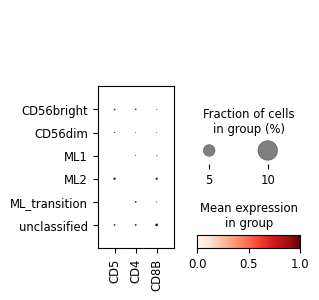

In [24]:
sc.pl.dotplot(
    adata_filtered,
    var_names=["CD5", "CD4", "CD8B"],  # genes (features)
    groupby="classification",          
    cmap='Reds',           
    standard_scale='var',    
    show=False)

plt.show()

In [25]:
#adata_filtered.write("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Fan_brain_met/Xing_rds/batch_none/Fan_nk_eMLclassified_adata_batch_none_classification_patientID_Tcell_filtered.h5ad")

In [26]:
#adata_filtered.obs.to_csv("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Fan_brain_met/Xing_rds/batch_none/Fan_nk_eMLclassified_adata_batch_none_classification_patientID_Tcell_filtered.csv")

In [24]:
# fan data T cell filtered
adata_filtered

AnnData object with n_obs × n_vars = 9086 × 33694
    obs: 'Disease', 'Study', 'SampleID', 'CancerType', 'CancerSubtype', 'EGFRtype', 'Treatment', 'Celltype', 'Subtype', 'batch', 'celltype.l2', 'dataset_name', 'classification', 'PatientID'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [25]:
fan_adata_filtered=adata_filtered.copy()

In [26]:
fan_adata_filtered

AnnData object with n_obs × n_vars = 9086 × 33694
    obs: 'Disease', 'Study', 'SampleID', 'CancerType', 'CancerSubtype', 'EGFRtype', 'Treatment', 'Celltype', 'Subtype', 'batch', 'celltype.l2', 'dataset_name', 'classification', 'PatientID'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

# Malmberg data

In [30]:
#load malm adata

In [ ]:
malm_adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification_allGenes.h5ad")

In [ ]:
malm_adata

AnnData object with n_obs × n_vars = 82408 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [ ]:
malm_adata.obs["patient_ID_v2"].nunique()

412

In [ ]:
malm_adata.obs["classification"].value_counts()

classification
CD56dim          65194
ML1               5371
CD56bright        4839
ML_transition     2898
ML2               2617
unclassified      1489
Name: count, dtype: int64

In [ ]:
malm_adata.obs["source"].value_counts()

source
lung_normal        23433
PBMC               23120
lung_tumor         17860
glioblastoma        5305
breast_tumor        4941
melanoma            2714
sarcoma             1621
pancreas_tumor      1104
pancreas_normal      655
breast_normal        603
prostate_tumor       530
prostate_normal      265
skin_normal          257
Name: count, dtype: int64

In [ ]:
# Get GBM from Malm data

In [ ]:
malm_adata_GBM= malm_adata[malm_adata.obs['source'] == 'glioblastoma'].copy()
malm_adata_GBM

AnnData object with n_obs × n_vars = 5305 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [ ]:
malm_adata_GBM.obs.rename(columns={'patient_ID_v2': 'patient'}, inplace=True)

In [ ]:
malm_adata_GBM

AnnData object with n_obs × n_vars = 5305 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [ ]:
malm_adata_GBM.obs["patient"].nunique()

98

In [ ]:
malm_adata_GBM.obs["classification"].value_counts()

classification
CD56dim          2679
ML1              1131
CD56bright        617
ML_transition     408
ML2               248
unclassified      222
Name: count, dtype: int64

In [ ]:
malm_adata_GBM.obs["source"].value_counts()

source
glioblastoma    5305
Name: count, dtype: int64

# Ding data

In [ ]:
# load ding data

In [ ]:
ding_adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Ding_lab/RNA/updated_batch/updated_batch_datasource_chemistry/nk_ding_eMLclassified_adata_batch_DataSource_Chemistry_classification_SourceType_v2_TcellFiltered.h5ad")

In [ ]:
ding_adata

AnnData object with n_obs × n_vars = 11170 × 36601
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cancer', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'Sample_RNA', 'Case_ID_RNA', 'S.Score', 'G2M.Score', 'Phase', 'Data.source', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC', 'classification', 'Source', 'Source_type', 'Source_type_v2'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [ ]:
ding_adata.obs.groupby("Source_type_v2")["Case_ID_RNA"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/3627542170.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ding_adata.obs.groupby("Source_type_v2")["Case_ID_RNA"].nunique()


Source_type_v2
BRCA_Met          1
BRCA_PT          16
Bone_marrow_N     3
CESC_PT           8
CRC_Met          12
CRC_PT            3
Colorectal_N      1
GBM_PT           13
HNSCC_PT         13
Kidney_N          2
MM_PT            10
OV_Met            2
OV_PT             3
PBMC              4
PDAC_Met          7
PDAC_PT          10
SKCM_Met         14
SKCM_PT           3
Skin_N            1
UCEC_Met          3
UCEC_PT           4
Uterus_N          1
ccRCC_PT         25
Name: Case_ID_RNA, dtype: int64

In [ ]:
ding_adata.obs["Source_type_v2"].value_counts()

Source_type_v2
ccRCC_PT         4082
MM_PT            2476
Bone_marrow_N    1345
PBMC              957
BRCA_PT           432
CRC_Met           390
GBM_PT            309
PDAC_PT           296
Kidney_N          184
SKCM_Met          130
OV_Met             99
UCEC_PT            94
HNSCC_PT           85
UCEC_Met           63
PDAC_Met           59
CESC_PT            50
OV_PT              47
Uterus_N           23
CRC_PT             17
Colorectal_N        9
BRCA_Met            9
SKCM_PT             7
Skin_N              7
Name: count, dtype: int64

In [ ]:
# Get GBM from Ding data

In [ ]:
ding_adata_GBM= ding_adata[ding_adata.obs['Source_type_v2'] == 'GBM_PT'].copy()
ding_adata_GBM

AnnData object with n_obs × n_vars = 309 × 36601
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cancer', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'Sample_RNA', 'Case_ID_RNA', 'S.Score', 'G2M.Score', 'Phase', 'Data.source', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC', 'classification', 'Source', 'Source_type', 'Source_type_v2'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [ ]:
ding_adata_GBM.obs.rename(columns={'Case_ID_RNA': 'patient'}, inplace=True)

In [ ]:
#rename Sample_RNA to sample
ding_adata_GBM.obs.rename(columns={'Sample_RNA': 'sample'}, inplace=True)

In [ ]:
#rename Source_type_v2 to source
ding_adata_GBM.obs.rename(columns={'Source_type_v2': 'source'}, inplace=True)

In [ ]:
ding_adata_GBM.obs['source'] = ding_adata_GBM.obs['source'].replace('GBM_PT', 'glioblastoma')

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/1497959894.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  ding_adata_GBM.obs['source'] = ding_adata_GBM.obs['source'].replace('GBM_PT', 'glioblastoma')


In [ ]:
ding_adata_GBM

AnnData object with n_obs × n_vars = 309 × 36601
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cancer', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'sample', 'patient', 'S.Score', 'G2M.Score', 'Phase', 'Data.source', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC', 'classification', 'Source', 'Source_type', 'source'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [ ]:
# now we have fan adata(adata_filtered), malm_adata and ding_adata

### Fan data renaming columns and filtering

In [27]:
adata_filtered.obs.rename(columns={'PatientID': 'patient'}, inplace=True)

In [28]:
adata_filtered.obs.groupby("CancerSubtype")["patient"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_30312/442716813.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_filtered.obs.groupby("CancerSubtype")["patient"].nunique()


CancerSubtype
BC-HR+HER2+     4
BC-HR+HER2-     2
BC-HR-HER2+     6
BC-TNBC         4
LC-SCLC         5
NSCLC-LCLC      3
NSCLC-LUAD     27
NSCLC-LUSC      3
Other          23
Name: patient, dtype: int64

In [29]:
adata_filtered.obs.groupby("CancerType")["patient"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_30312/2367943084.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_filtered.obs.groupby("CancerType")["patient"].nunique()


CancerType
BC         16
CRC         7
ESCC        3
HCC         3
LC         39
MEL         1
Other       4
Sarcoma     4
Name: patient, dtype: int64

In [ ]:
# fan data filtering for bar plot BrM LUAD and BrM BC 

In [30]:
exclude_subtypes = ['LC-SCLC', 'NSCLC-LCLC', 'NSCLC-LUSC', 'Other']
fan_adata = adata_filtered[~adata_filtered.obs['CancerSubtype'].isin(exclude_subtypes)].copy()

In [32]:
fan_adata

AnnData object with n_obs × n_vars = 4853 × 33694
    obs: 'Disease', 'Study', 'SampleID', 'CancerType', 'CancerSubtype', 'EGFRtype', 'Treatment', 'Celltype', 'Subtype', 'batch', 'celltype.l2', 'dataset_name', 'classification', 'patient'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [31]:
fan_adata.obs.groupby("CancerSubtype")["patient"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_30312/1806068637.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fan_adata.obs.groupby("CancerSubtype")["patient"].nunique()


CancerSubtype
BC-HR+HER2+     4
BC-HR+HER2-     2
BC-HR-HER2+     6
BC-TNBC         4
NSCLC-LUAD     27
Name: patient, dtype: int64

In [33]:
fan_adata_LB = fan_adata[fan_adata.obs['CancerType'].isin(['LC', 'BC'])].copy()

In [34]:
fan_adata_LB

AnnData object with n_obs × n_vars = 4853 × 33694
    obs: 'Disease', 'Study', 'SampleID', 'CancerType', 'CancerSubtype', 'EGFRtype', 'Treatment', 'Celltype', 'Subtype', 'batch', 'celltype.l2', 'dataset_name', 'classification', 'patient'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [35]:
fan_adata_LB.obs["classification"].value_counts()

classification
CD56dim          2540
ML1               983
ML_transition     448
CD56bright        406
ML2               277
unclassified      199
Name: count, dtype: int64

In [ ]:
fan_adata_LB.obs["CancerSubtype"].value_counts()

CancerSubtype
NSCLC-LUAD     3801
BC-HR-HER2+     623
BC-HR+HER2+     321
BC-HR+HER2-      54
BC-TNBC          54
Name: count, dtype: int64

In [ ]:
fan_adata_LB.obs.rename(columns={'CancerType': 'source'}, inplace=True)

In [ ]:
fan_adata_LB.obs["source"].value_counts()

source
LC    3801
BC    1052
Name: count, dtype: int64

In [ ]:
fan_adata_LB.obs.rename(columns={'SampleID': 'sample'}, inplace=True)

In [ ]:
malm_adata_GBM.obs['dataset_source'] = 'malm'
ding_adata_GBM.obs['dataset_source'] = 'ding'
fan_adata_LB.obs['dataset_source'] = 'fan'

In [ ]:
malm_adata_GBM

AnnData object with n_obs × n_vars = 5305 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient', 'classification', 'dataset_source'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [ ]:
ding_adata_GBM

AnnData object with n_obs × n_vars = 309 × 36601
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'Sample_ATAC', 'Cancer', 'Sample_type', 'Chemistry', 'cell_type.atac', 'cell_type.harmonized.cancer', 'Piece_ID_RNA', 'data.type.rna', 'sample', 'patient', 'S.Score', 'G2M.Score', 'Phase', 'Data.source', 'Batches', 'integrated_snn_res.2', 'cell_type_v8_allRNA2', 'cell_type_v8.0_Tcell', 'cell_type_v8.2_rna', 'integrated_snn_res.1', 'integrated_snn_res.1.5', 'cell_type_v8.5_rna', 'integrated_snn_res.1.3', 'cell_type_v8.5_multi', 'integrated_snn_res.2.5', 'cell_type_v8.6_rna', 'cell_type_v8.7_rna', 'Sample.source', 'Tissue.normal', 'Data.source_Chemistry', 'batch', 'celltype.l2', 'dataset_name', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC', 'classification', 'Source', 'Source_type', 'source', 'dataset_source'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [ ]:
fan_adata_LB

AnnData object with n_obs × n_vars = 4853 × 33694
    obs: 'Disease', 'Study', 'sample', 'source', 'CancerSubtype', 'EGFRtype', 'Treatment', 'Celltype', 'Subtype', 'batch', 'celltype.l2', 'dataset_name', 'classification', 'patient', 'dataset_source'
    uns: 'log1p'
    obsm: 'protein_expression'
    layers: 'counts'

In [ ]:
import anndata as ad

# combining data with required columns

In [ ]:
# Subset .obs to only the needed columns
required_obs_columns = ['source', 'sample', 'patient','classification', 'dataset_source']

for adata in [malm_adata_GBM, ding_adata_GBM, fan_adata_LB]:
    adata.obs = adata.obs[required_obs_columns]

# Step 3: Concatenate the datasets
combined_adata = ad.concat(
    [malm_adata_GBM, ding_adata_GBM, fan_adata_LB],
    join='inner',      # Keep only genes/features common to all
    merge='same'       # Ensure .obs columns are aligned by name and type
)

print(combined_adata)
print(combined_adata.obs['dataset_source'].value_counts())

AnnData object with n_obs × n_vars = 10467 × 14337
    obs: 'source', 'sample', 'patient', 'classification', 'dataset_source'
dataset_source
malm    5305
fan     4853
ding     309
Name: count, dtype: int64


/Users/vedanagapriyavangala/Library/Python/3.9/lib/python/site-packages/anndata/_core/merge.py:1362: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [ ]:
combined_adata.obs

,source,sample,patient,classification,dataset_source
3182_1574-0_goswami_3182,glioblastoma,3182,3182_goswami,CD56dim,malm
3182_1582-0_goswami_3182,glioblastoma,3182,3182_goswami,CD56dim,malm
3282_611-0_goswami_3282,glioblastoma,3282,3282_goswami,CD56dim,malm
3295_78-0_goswami_3295,glioblastoma,3295,3295_goswami,CD56dim,malm
3295_79-0_goswami_3295,glioblastoma,3295,3295_goswami,CD56dim,malm
...,...,...,...,...,...
Xing_BrM95_LC_TTGCTGCAGGAAAGGT,LC,BrM95,BrM95,ML1,fan
Xing_BrM95_LC_TTGTGTTGTTTCACAG,LC,BrM95,BrM95,ML1,fan
Xing_BrM95_LC_TTTATGCCAAGTGATA,LC,BrM95,BrM95,unclassified,fan
Xing_BrM95_LC_TTTCAGTAGCGCTGCT,LC,BrM95,BrM95,CD56dim,fan


In [ ]:
#combined_adata.obs.to_csv("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/output/fan_BC_LUAD_malm_GBM_ding_GBM.csv")

# Bar plot comparing GBM(malm+ding) vs BrM_LC and BrM_BC

In [ ]:
plt.rcParams['figure.dpi'] = 600

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/2528239401.py:8: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  obs['classification_stacked'] = obs['classification'].replace({
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/2528239401.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_stacked = obs.groupby(['source', 'sample', 'classification_stacked']).size().unstack(fill_value=0)
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/2528239401.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to 

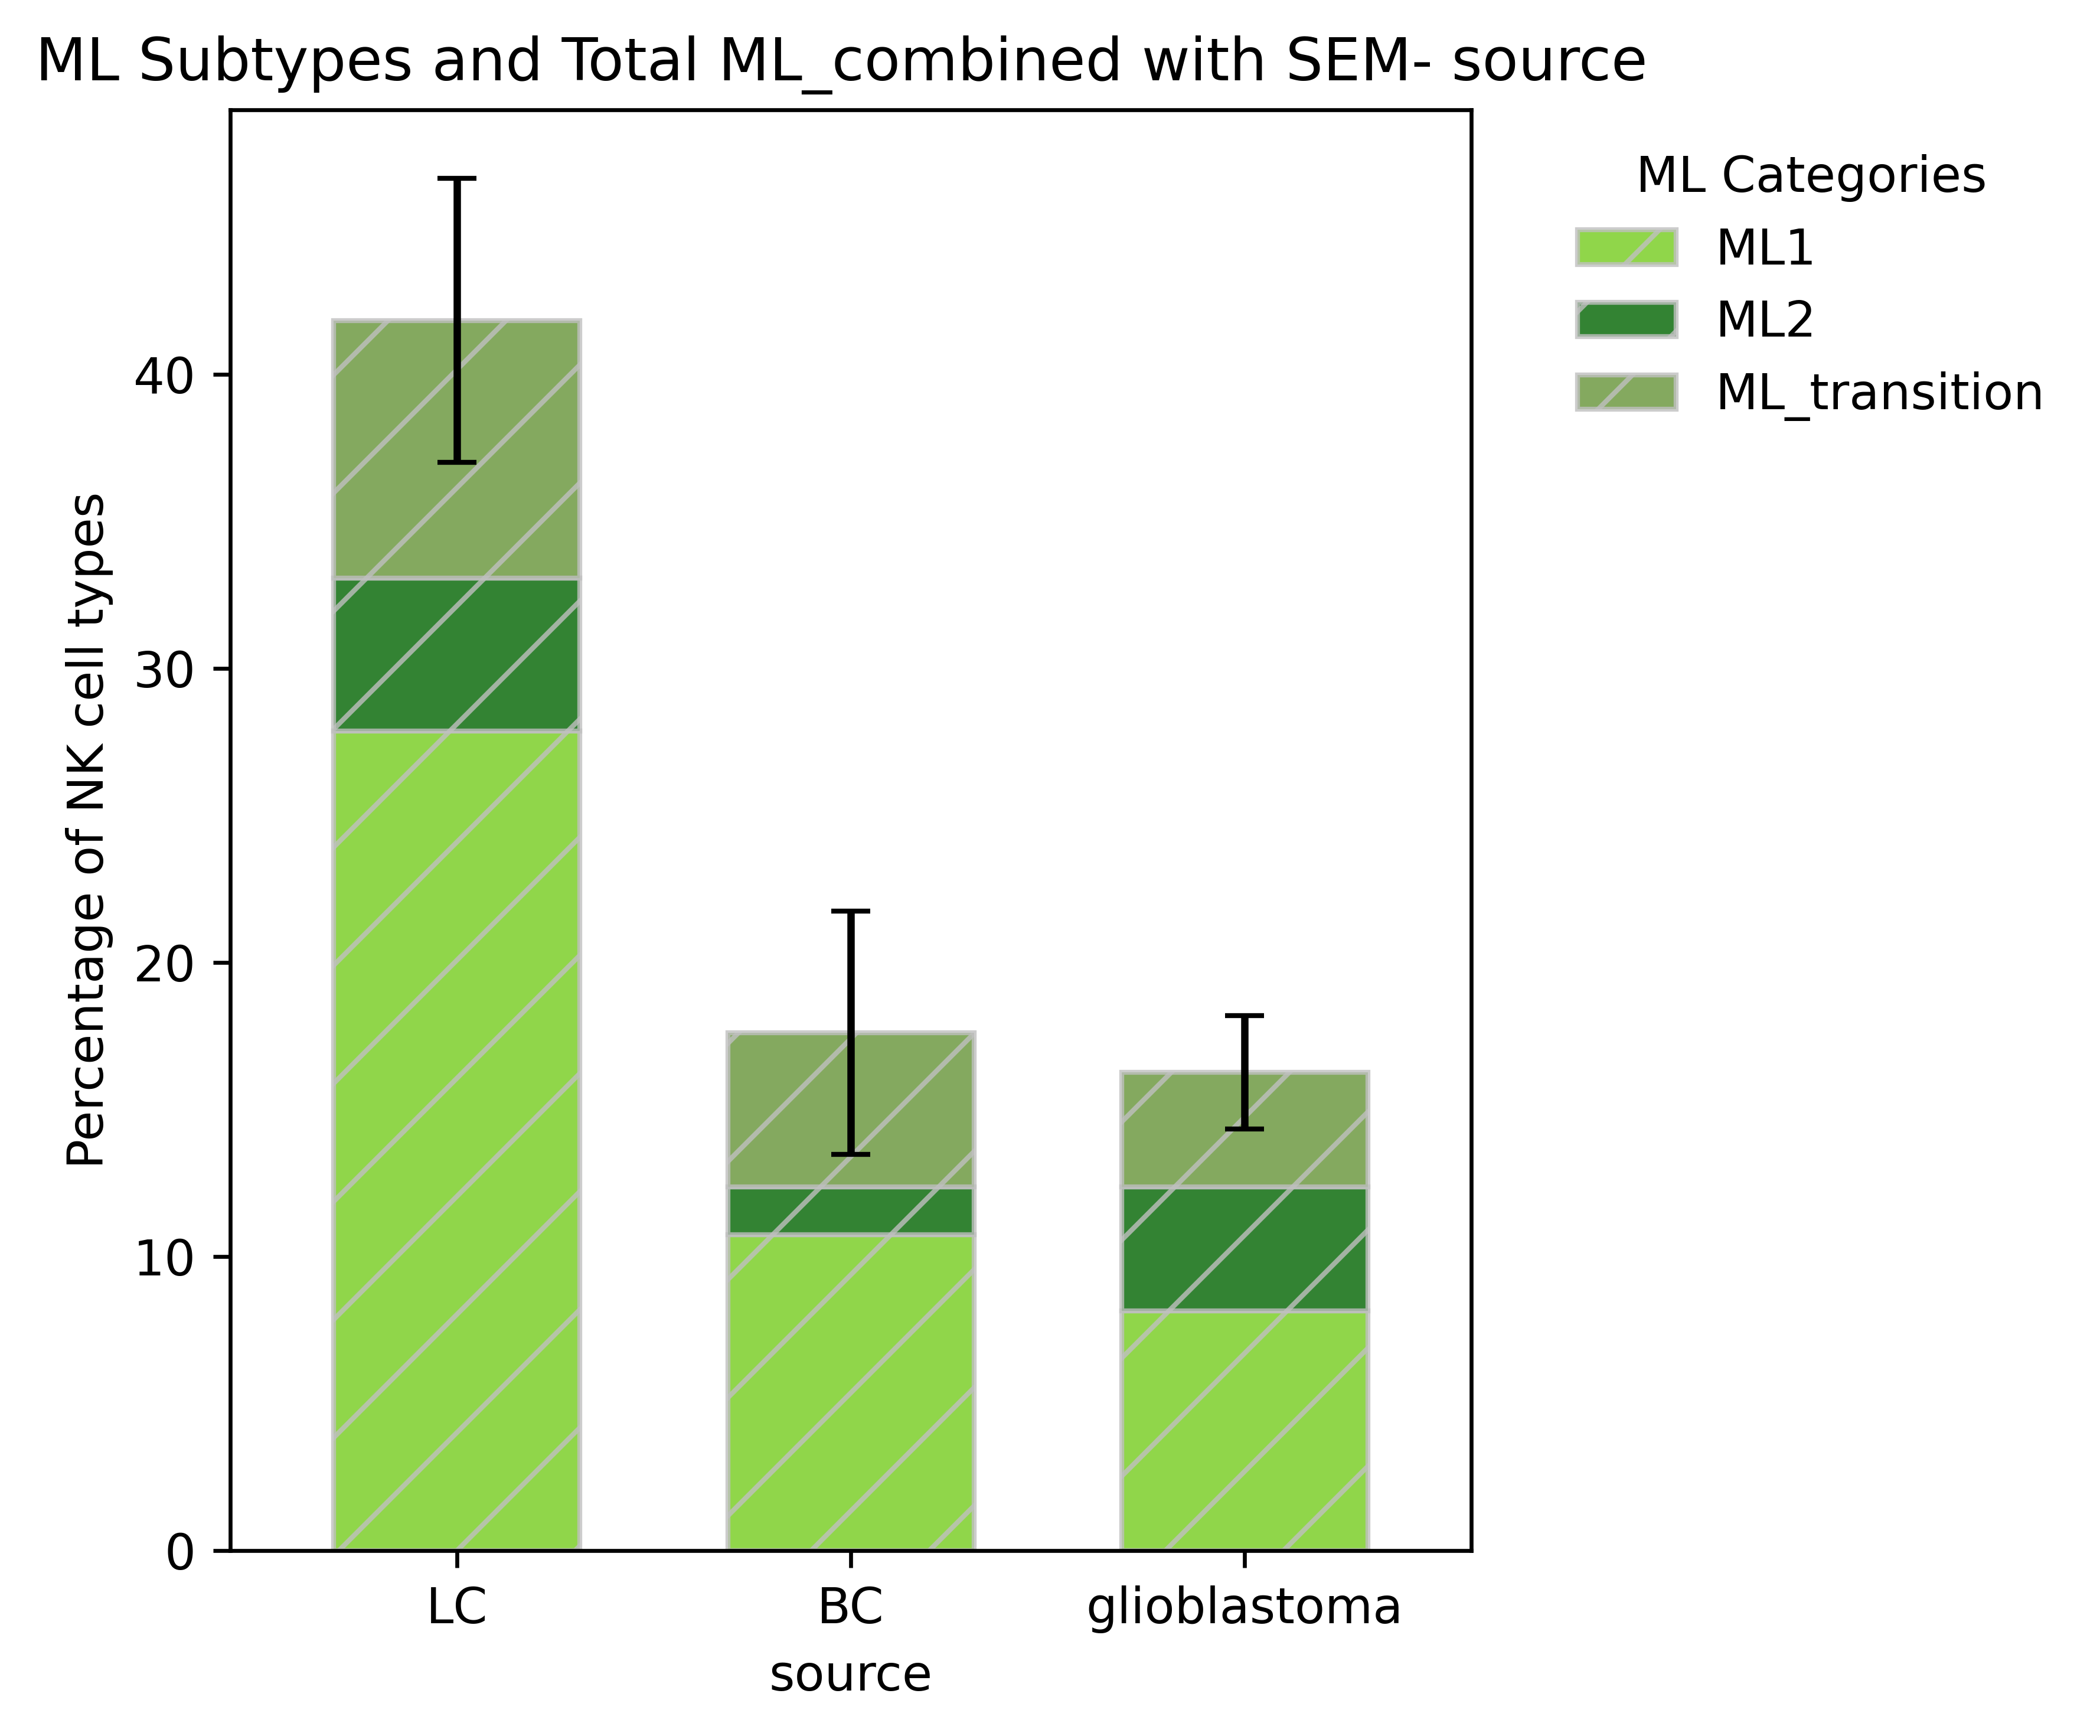

In [ ]:
# Copy obs from adata
obs = combined_adata.obs.copy()
obs['source'] = obs['source'].cat.remove_unused_categories()

# Stacked Bar Breakdown

# Preserve ML1, ML2, ML_transition for visual breakdown
obs['classification_stacked'] = obs['classification'].replace({
    'ML1': 'ML_combined_ML1',
    'ML2': 'ML_combined_ML2',
    'ML_transition': 'ML_combined_ML_transition'
})

# Calculate per-sample percentages for stacked bar
grouped_stacked = obs.groupby(['source', 'sample', 'classification_stacked']).size().unstack(fill_value=0)
percentages_stacked = grouped_stacked.div(grouped_stacked.sum(axis=1), axis=0) * 100
ml_categories = ['ML_combined_ML1', 'ML_combined_ML2', 'ML_combined_ML_transition']
mean_ml = percentages_stacked.groupby('source')[ml_categories].mean()

# SEM for Combined ML 

# Collapse ML1/2/transition into ML_combined (per sample)
obs_sem = combined_adata.obs.copy()
obs_sem = obs_sem[obs_sem['source'] != 'Other']
obs_sem['source'] = obs_sem['source'].cat.remove_unused_categories()

obs_sem['classification'] = obs_sem['classification'].replace({
    'ML1': 'ML_combined', 'ML2': 'ML_combined', 'ML_transition': 'ML_combined'
})
grouped_sem = obs_sem.groupby(['source', 'sample','classification']).size().unstack(fill_value=0)
percentages_sem = grouped_sem.div(grouped_sem.sum(axis=1), axis=0) * 100

# Mean and SEM of total ML_combined percentage
mean_ml_combined = percentages_sem.groupby('source')['ML_combined'].mean()
sem_ml_combined = percentages_sem.groupby('source')['ML_combined'].sem()

sorted_index = mean_ml.sum(axis=1).sort_values(ascending=False).index
mean_ml = mean_ml.loc[sorted_index]
mean_ml_combined = mean_ml_combined.loc[sorted_index]
sem_ml_combined = sem_ml_combined.loc[sorted_index]


# Customizing Plot

plt.figure(figsize=(6, 5))
x = np.arange(len(mean_ml.index))*0.4
width = 0.25
colors = {
    'ML_combined_ML1': '#74cc1d',
    'ML_combined_ML2': 'darkgreen',
    'ML_combined_ML_transition': '#659437'
}

# Stack bars
bottom = np.zeros(len(mean_ml.index))
for category in ml_categories:
    bars = plt.bar(
        x,
        mean_ml[category],
        width=width,
        label=category.replace('ML_combined_', ''),
        color=colors[category],
        alpha=0.8,
        bottom=bottom, hatch='/', edgecolor='silver',
    )
    bottom += mean_ml[category]

# Add error bars on top of stacked bars
plt.errorbar(
    x,
    bottom,  # Top of the stacked bars
    yerr=sem_ml_combined,
    fmt='none',
    color='black',
    capsize=4,
    elinewidth=1.5
)

# Formatting
plt.xticks(x, mean_ml.index, rotation=0)
plt.ylabel("Percentage of NK cell types")
plt.xlabel("source")
plt.title("ML Subtypes and Total ML_combined with SEM- source ")
plt.margins(x=0.10)
plt.legend(title="ML Categories",bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, )
plt.tight_layout()
plt.show()

In [ ]:
obs.groupby("source")["patient"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/2458983108.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs.groupby("source")["patient"].nunique()


source
BC               16
LC               27
glioblastoma    111
Name: patient, dtype: int64

# Bar plot comparing BrM_LUAD(fan) vs LUAD(malm lung matched)

In [ ]:
# filtering adata by patients with multiple sources and focus on lung in malmberg data

In [ ]:
# Count unique sources per patient
patient_source_counts = malm_adata.obs.groupby("patient_ID_v2")["source"].nunique()

# Identify patients with >1 unique source
patients_multiple_sources = patient_source_counts[patient_source_counts > 1].index

# Filter adata to only include those patients
malm_adata_filtered = malm_adata[malm_adata.obs["patient_ID_v2"].isin(patients_multiple_sources)].copy()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/1393046554.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_source_counts = malm_adata.obs.groupby("patient_ID_v2")["source"].nunique()


In [ ]:
malm_adata_filtered.obs["source"].value_counts()

source
lung_normal        20361
lung_tumor         11571
pancreas_normal      651
prostate_normal      265
pancreas_tumor       246
prostate_tumor       233
Name: count, dtype: int64

In [ ]:
malm_adata_filtered = malm_adata_filtered[malm_adata_filtered.obs["source"].isin(["lung_normal", "lung_tumor"])].copy()

In [ ]:
malm_adata_filtered

AnnData object with n_obs × n_vars = 31932 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [ ]:
malm_adata_filtered.obs["patient_ID_v2"].nunique()

61

In [ ]:
unique_counts = malm_adata_filtered.obs.groupby('dataset_v2')['patient_ID_v2'].nunique()

print(unique_counts)

dataset_v2
bischoff        8
chan            2
kim            10
lambrechts      7
leader         22
leader_cite     8
he_D            5
Name: patient_ID_v2, dtype: int64


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/255267343.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unique_counts = malm_adata_filtered.obs.groupby('dataset_v2')['patient_ID_v2'].nunique()


In [ ]:
# include only patients who are LUAD and excluding other ones
# leader -3
# leader_cite -2
# lambrechts -4

In [ ]:
lambrechts = malm_adata_filtered.obs[malm_adata_filtered.obs['dataset_v2'] == 'lambrechts']

In [ ]:
lambrechts["patient_ID_v2"].unique()

['p2_lambrechts', 'p3_lambrechts', 'p4_lambrechts', 'p5_lambrechts', 'p7_lambrechts', 'p8_lambrechts', 'p6_lambrechts']
Categories (61, object): ['06_kim', '08_kim', '09_kim', '18_kim', ..., 'p031_bischoff', 'p032_bischoff', 'p033_bischoff', 'p034_bischoff']

In [ ]:
# List of IDs to exclude from each dataset
exclude_leader_ids = ['706', '522', '584', '377', '714']
exclude_lambrechts_ids = ['p2_lambrechts', 'p5_lambrechts', 'p7_lambrechts', 'p8_lambrechts']

# Filter the AnnData object
malm_adata_filtered_LUAD = malm_adata_filtered[
    ~(
        ((malm_adata_filtered.obs['dataset_v2'].isin(['leader', 'leader_cite'])) &
         (malm_adata_filtered.obs['patient_ID_v2'].isin(exclude_leader_ids)))
        |
        ((malm_adata_filtered.obs['dataset_v2'] == 'lambrechts') &
         (malm_adata_filtered.obs['patient_ID_v2'].isin(exclude_lambrechts_ids)))
    )]

In [ ]:
malm_adata_filtered_LUAD.obs["patient_ID_v2"].nunique()

52

In [ ]:
# Create a boolean mask to check for what will be excluded
exclusion_mask = (
    ((malm_adata_filtered.obs['dataset_v2'].isin(['leader', 'leader_cite'])) &
     (malm_adata_filtered.obs['patient_ID_v2'].isin(exclude_leader_ids))) |
    ((malm_adata_filtered.obs['dataset_v2'] == 'lambrechts') &
     (malm_adata_filtered.obs['patient_ID_v2'].isin(exclude_lambrechts_ids))))

In [ ]:
excluded_cells = malm_adata_filtered[exclusion_mask]
print(excluded_cells.obs[['dataset_v2', 'patient_ID_v2']].value_counts())

dataset_v2   patient_ID_v2
lambrechts   p8_lambrechts    741
leader       714              529
leader_cite  584              444
lambrechts   p5_lambrechts    441
leader_cite  706              431
lambrechts   p7_lambrechts    280
             p2_lambrechts    230
leader       522              146
             377               75
Name: count, dtype: int64


In [ ]:
malm_adata_filtered_LUAD.obs.rename(columns={'patient_ID_v2': 'patient'}, inplace=True)

In [ ]:
malm_adata_filtered_LUAD

View of AnnData object with n_obs × n_vars = 28615 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [ ]:
fan_adata_BrM_LUAD= fan_adata_filtered[fan_adata_filtered.obs['CancerSubtype'] =='NSCLC-LUAD'].copy()

In [ ]:
fan_adata_BrM_LUAD.obs.rename(columns={'CancerSubtype': 'source'}, inplace=True)
fan_adata_BrM_LUAD.obs.rename(columns={'SampleID': 'sample'}, inplace=True)
fan_adata_BrM_LUAD.obs.rename(columns={'PatientID': 'patient'}, inplace=True)

In [ ]:
malm_adata_filtered_LUAD.obs['dataset_source'] = 'malm'
fan_adata_BrM_LUAD.obs['dataset_source'] = 'fan'

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/3656799107.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  malm_adata_filtered_LUAD.obs['dataset_source'] = 'malm'


In [ ]:
# Subset .obs to only the needed columns
required_obs_columns = ['source', 'sample', 'classification', 'dataset_source', 'patient']

for adata in [malm_adata_filtered_LUAD, fan_adata_BrM_LUAD]:
    adata.obs = adata.obs[required_obs_columns]

# Concatenate the datasets
combined_adata = ad.concat(
    [malm_adata_filtered_LUAD,  fan_adata_BrM_LUAD],
    join='inner',      
    merge='same')

print(combined_adata)
print(combined_adata.obs['dataset_source'].value_counts())

AnnData object with n_obs × n_vars = 32416 × 14337
    obs: 'source', 'sample', 'classification', 'dataset_source', 'patient'
dataset_source
malm    28615
fan      3801
Name: count, dtype: int64


/Users/vedanagapriyavangala/Library/Python/3.9/lib/python/site-packages/anndata/_core/merge.py:1362: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [ ]:
combined_adata_ex_lungN= combined_adata[combined_adata.obs['source'] != 'lung_normal'].copy()

In [ ]:
combined_adata_ex_lungN

AnnData object with n_obs × n_vars = 13892 × 14337
    obs: 'source', 'sample', 'classification', 'dataset_source', 'patient'

In [ ]:
combined_adata_ex_lungN.obs["source"].value_counts()

source
lung_tumor    10091
NSCLC-LUAD     3801
Name: count, dtype: int64

In [ ]:
#combined_adata_ex_lungN.obs.to_csv("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/output/fan_BrM_LUAD_vs_malm_prim_LUAD_matched_pts.csv")

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/3289936048.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  obs['classification_stacked'] = obs['classification'].replace({
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/3289936048.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_stacked = obs.groupby(['source', 'sample', 'classification_stacked']).size().unstack(fill_value=0)
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_15291/3289936048.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to 

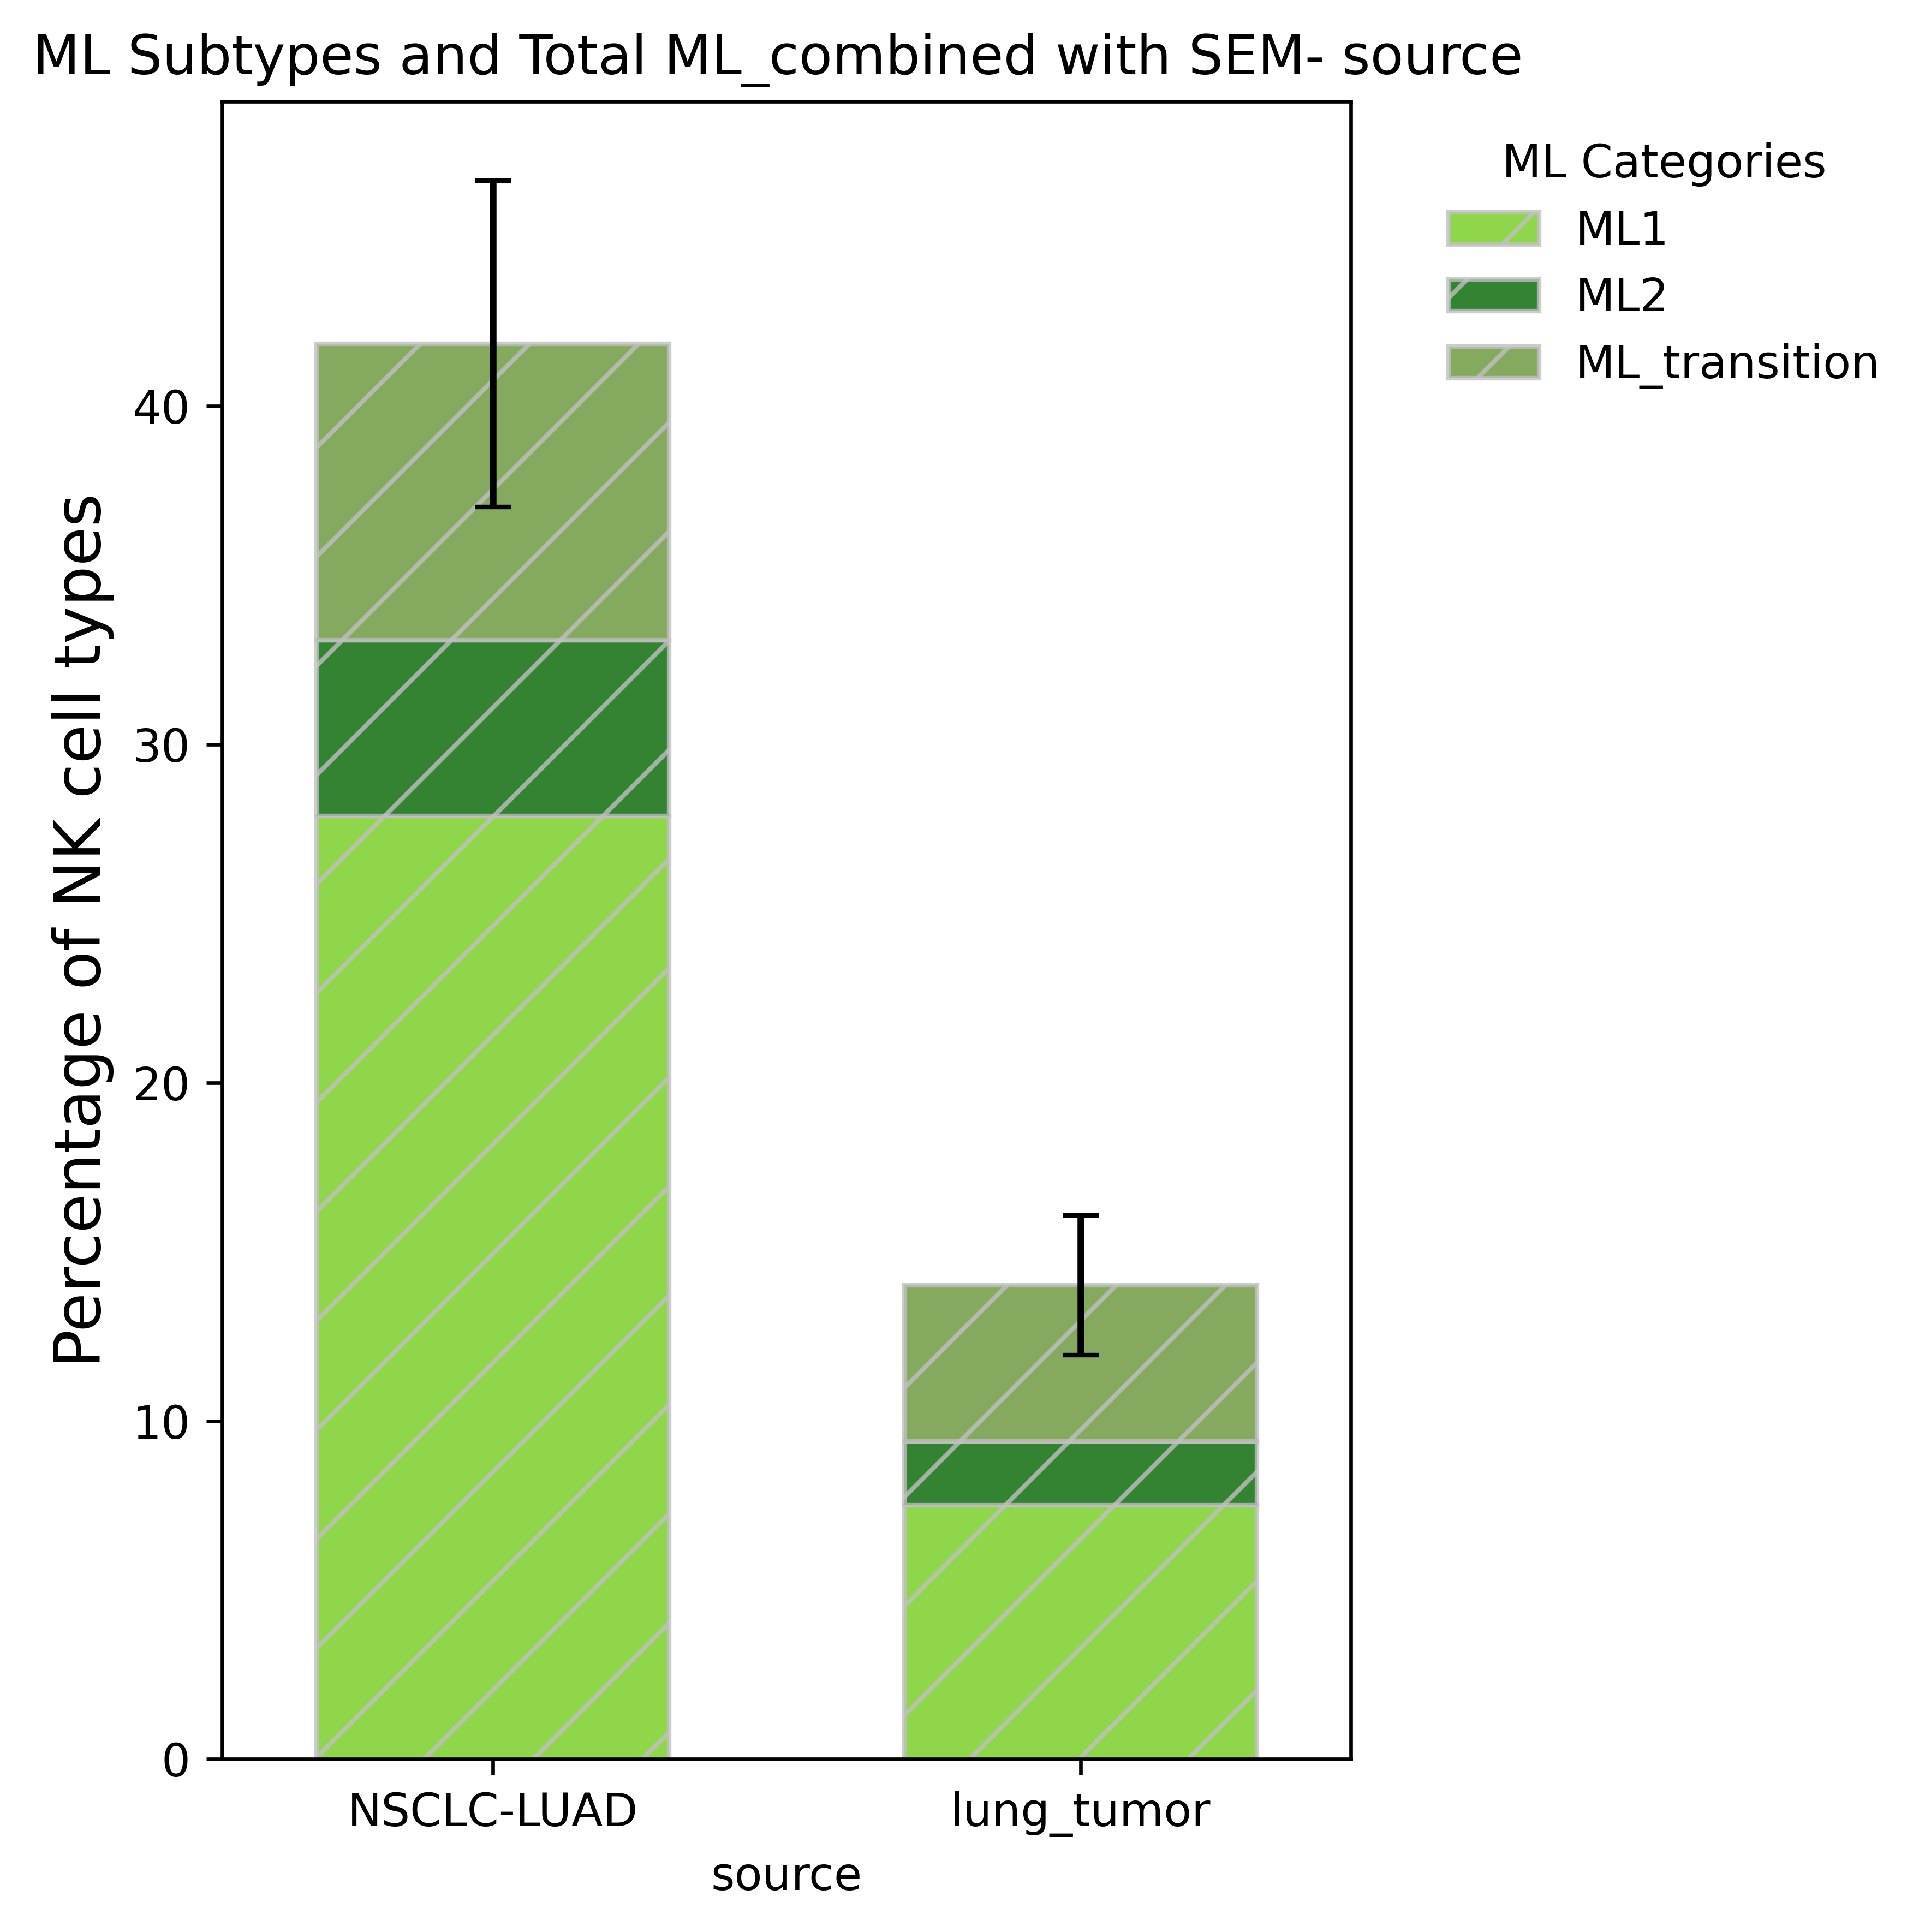

In [ ]:
# Copy obs from adata
obs = combined_adata_ex_lungN.obs.copy()
obs = obs[obs['source'] != 'Other'] 
obs['source'] = obs['source'].cat.remove_unused_categories()

# Stacked Bar Breakdown
# Preserve ML1, ML2, ML_transition for visual breakdown
obs['classification_stacked'] = obs['classification'].replace({
    'ML1': 'ML_combined_ML1',
    'ML2': 'ML_combined_ML2',
    'ML_transition': 'ML_combined_ML_transition'
})

# Calculate per-sample percentages for stacked bar
grouped_stacked = obs.groupby(['source', 'sample', 'classification_stacked']).size().unstack(fill_value=0)
percentages_stacked = grouped_stacked.div(grouped_stacked.sum(axis=1), axis=0) * 100
ml_categories = ['ML_combined_ML1', 'ML_combined_ML2', 'ML_combined_ML_transition']
mean_ml = percentages_stacked.groupby('source')[ml_categories].mean()

# SEM for Combined ML 

# Collapse ML1/2/transition into ML_combined (per sample)
obs_sem = combined_adata_ex_lungN.obs.copy()
obs_sem = obs_sem[obs_sem['source'] != 'Other']
obs_sem['source'] = obs_sem['source'].cat.remove_unused_categories()

obs_sem['classification'] = obs_sem['classification'].replace({
    'ML1': 'ML_combined', 'ML2': 'ML_combined', 'ML_transition': 'ML_combined'
})
grouped_sem = obs_sem.groupby(['source', 'sample','classification']).size().unstack(fill_value=0)
percentages_sem = grouped_sem.div(grouped_sem.sum(axis=1), axis=0) * 100

# Mean and SEM of total ML_combined percentage
mean_ml_combined = percentages_sem.groupby('source')['ML_combined'].mean()
sem_ml_combined = percentages_sem.groupby('source')['ML_combined'].sem()

#sorted_index = mean_ml.sum(axis=1).sort_values(ascending=False).index
#mean_ml = mean_ml.loc[sorted_index]
#mean_ml_combined = mean_ml_combined.loc[sorted_index]
#sem_ml_combined = sem_ml_combined.loc[sorted_index]


# Customizing Plot 

plt.figure(figsize=(6, 6))
x = np.arange(len(mean_ml.index))*0.5
width = 0.3
colors = {
    'ML_combined_ML1': '#74cc1d',
    'ML_combined_ML2': 'darkgreen',
    'ML_combined_ML_transition': '#659437'}

# Stack bars
bottom = np.zeros(len(mean_ml.index))
for category in ml_categories:
    bars = plt.bar(
        x,
        mean_ml[category],
        width=width,
        label=category.replace('ML_combined_', ''),
        color=colors[category],
        alpha=0.8,
        bottom=bottom,
        hatch='/', edgecolor='silver',
    )
    bottom += mean_ml[category]

# Add error bars on top of stacked bars
plt.errorbar(
    x,
    bottom,  # Top of the stacked bars
    yerr=sem_ml_combined,
    fmt='none',
    color='black',
    capsize=4,
    elinewidth=1.5)

# Formatting
plt.xticks(x, mean_ml.index, rotation=0)
plt.ylabel("Percentage of NK cell types", fontsize=14 )
plt.xlabel("source")
plt.title("ML Subtypes and Total ML_combined with SEM- source ")
plt.margins(x=0.10)
plt.legend(title="ML Categories",bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, )
plt.tight_layout()
plt.show()